# Exploratory analysis of the Moviever Database
### In this Notebook we take a look at the data provided in TMDB_movies.csv

The data went through the cleaning pipeline and was then studied and used to find meaningful metrics that serve as building blocks for our business model.


![Pipeline](pipeline_diagram.png)


## How to run:

`python clean.py --in data/TMDB_movies.csv --out data/TMDB_movies_clean.csv`

replace the in and out path with the expanded tmdb csv


### Imports:


In [84]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

We load the **cleaned output** from the pipeline (`TMDB_movies_clean.csv`) rather than re-cleaning inside the notebook.

In [85]:
df = pd.read_csv("data/TMDB_movies_clean.csv")
df.shape, df.columns[:10]

((4803, 32),
 Index(['id', 'title', 'original_title', 'release_date', 'release_year',
        'original_language', 'overview', 'status', 'tagline', 'primary_genre'],
       dtype='str'))

## Restore tag columns for analysis (critical for marketing + recommendations)

Several of our most valuable business features are the parsed “name” columns from TMDB JSON fields:
 - `genres_names`, `keywords_names`, `production_companies_names`, etc.

When those lists are saved to CSV, they appear as strings like:
`['Action', 'Drama']`

We convert them back to Python lists so we can:
- build shelves/collections (“Underdog”, “Heist”, “Coming-of-age”)
- count tags for segmentation
- compute overlaps for simple recommendation logic

This step supports the goal: **use tags to persuade customers and drive adoption** of a physical rental service.

In [86]:
name_cols = [c for c in df.columns if c.endswith("_names")]

def safe_literal_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.strip() == "":
        return []
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else []
    except Exception:
        return []

for c in name_cols:
    df[c] = df[c].apply(safe_literal_list)

df[name_cols].head(2)

,genres_names,keywords_names,production_companies_names,production_countries_names,spoken_languages_names
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]","[English, Español]"
1,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],[English]


We set the dataframe index to `id` because it’s the most stable unique identifier in the dataset.

In [87]:
if "id" in df.columns:
    df = df.set_index("id", drop=False)

df.index.name, df.index.is_unique

('id', True)

Before we trust any metric, we check **missingness** to understand:
- what’s complete enough for analysis (votes, popularity, tags)
- what’s incomplete and must be treated carefully (budget/revenue)

In [88]:
missing = df.isna().mean().sort_values(ascending=False).head(12)
missing

roi                           0.330835
profit                        0.327712
revenue                       0.297106
budget                        0.215907
tagline                       0.175724
primary_genre                 0.005830
overview                      0.000625
runtime                       0.000416
release_year                  0.000208
release_date                  0.000208
keywords_names                0.000000
production_companies_names    0.000000
dtype: float64

## Preview: segmentation features (tags are the main asset)

Here we confirm that the core “marketing + recommendation” features are usable at a glance:
- `primary_genre` for catalogue grouping
- `genres_names` and `keywords_names` for shelf design and campaign messaging

This is the most important proof point for the business: **the dataset can describe movies in customer language**.

In [89]:
# Confirm we have useful tag-like info for business segmentation
df[["title", "primary_genre", "genres_names", "keywords_names"]].head(5)

,title,primary_genre,genres_names,keywords_names
id,,,,
19995,Avatar,Action,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon..."
285,Pirates of the Caribbean: At World's End,Adventure,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ..."
206647,Spectre,Action,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi..."
49026,The Dark Knight Rises,Action,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i..."
49529,John Carter,Action,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel..."


## Chart 1: Budget vs Revenue (theatrical traction proxy)

Even though the rental business doesn’t earn theatrical revenue, budget vs revenue still helps us:
- understand the **scale** of films in the catalogue
- identify outliers (unexpectedly strong or weak performance)
- frame ROI/profit as a *contextual signal*, not the only decision factor

We filter to rows where budget and revenue are present and positive so the plot is meaningful.
We also use log scales because film budgets/revenues span multiple orders of magnitude.

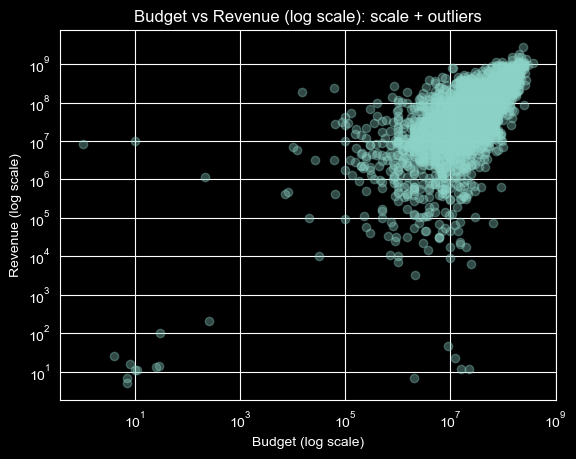

In [90]:
plot_df = df.dropna(subset=["budget", "revenue"]).copy()

# guard against weird negatives (shouldn't exist, but safe)
plot_df = plot_df[(plot_df["budget"] > 0) & (plot_df["revenue"] > 0)]

plt.figure()
plt.scatter(plot_df["budget"], plot_df["revenue"], alpha=0.35)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget (log scale)")
plt.ylabel("Revenue (log scale)")
plt.title("Budget vs Revenue (log scale): scale + outliers")
plt.show()

## Break-even reference line
We add a break-even line where `revenue = budget`.

This makes the chart easier for stakeholders:
- points above the line out-earned budget (market traction)
- points below the line under-earned budget (risk / weak traction)

It’s a simple visual that supports catalogue conversations without heavy statistics.

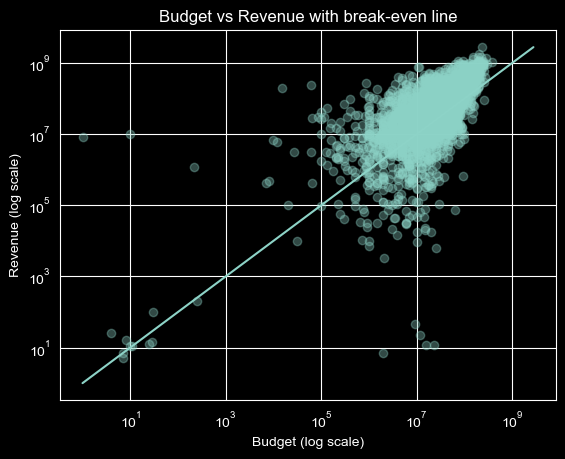

In [91]:
plt.figure()
plt.scatter(plot_df["budget"], plot_df["revenue"], alpha=0.35)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget (log scale)")
plt.ylabel("Revenue (log scale)")
plt.title("Budget vs Revenue with break-even line")

# break-even line
minv = min(plot_df["budget"].min(), plot_df["revenue"].min())
maxv = max(plot_df["budget"].max(), plot_df["revenue"].max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()

 ## Chart 2: Rating vs vote count
 
 For a physical rental service, customer adoption depends on **trust**.
 
 `vote_average` alone can be misleading if very few people voted.
 So we compare:
 - **vote_average** (how much people liked it)
 - **vote_count** (how confident we are that rating is reliable)
 
 This separates:
 - “crowd-validated anchors” (high votes + strong rating)
 - “niche gems” (strong rating but fewer votes)
 
 Both groups are useful: anchors build adoption; niche gems differentiate the shop.

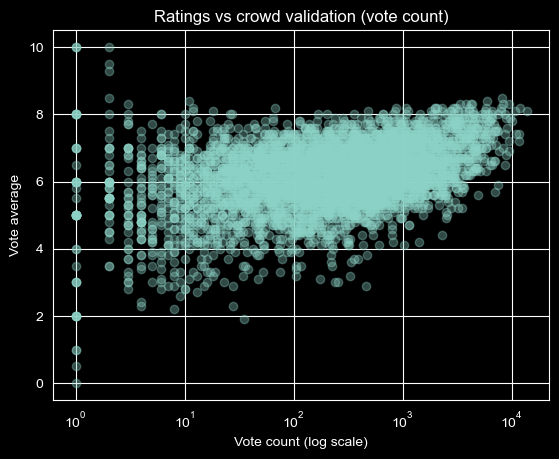

In [92]:
plot_df = df.dropna(subset=["vote_average", "vote_count"]).copy()
plot_df = plot_df[plot_df["vote_count"] > 0]

plt.figure()
plt.scatter(plot_df["vote_count"], plot_df["vote_average"], alpha=0.35)
plt.xscale("log")
plt.xlabel("Vote count (log scale)")
plt.ylabel("Vote average")
plt.title("Ratings vs crowd validation (vote count)")
plt.show()

## Extract “anchor candidates” from Chart 2

This cell turns the chart into an actionable output:
we select the top slice of films by **vote_count** and **vote_average**.

This is an initial shortlist of “safe bets” to stock and promote early,
reducing friction for new customers trying the service for the first time.

In [93]:
top = plot_df[(plot_df["vote_count"] >= plot_df["vote_count"].quantile(0.90)) &
              (plot_df["vote_average"] >= plot_df["vote_average"].quantile(0.90))]
top[["title", "vote_average", "vote_count", "primary_genre"]].head(15)

,title,vote_average,vote_count,primary_genre
id,,,,
49026,The Dark Knight Rises,7.6,9106,Action
38757,Tangled,7.4,3330,Animation
99861,Avengers: Age of Ultron,7.3,6767,Action
767,Harry Potter and the Half-Blood Prince,7.4,5293,Adventure
24428,The Avengers,7.4,11776,Science Fiction
57158,The Hobbit: The Desolation of Smaug,7.6,4524,Adventure
597,Titanic,7.5,7562,Drama
10193,Toy Story 3,7.6,4597,Animation
168259,Furious 7,7.3,4176,Action


## Chart 3: Median ROI by year (subset only)

ROI is computed only where budget and revenue are known (and not suspiciously tiny).

We plot **median ROI by release year** to show how returns vary across eras,
which can inform catalogue structuring such as:
- classic decades vs modern eras
- anniversary promotions
- balancing “reliable crowd-pleasers” with discovery titles

Important: this chart describes only a subset of films, so we treat it as directional context.

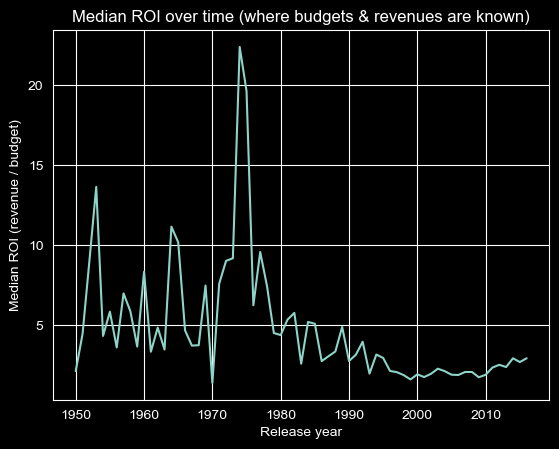

In [94]:
plot_df = df.dropna(subset=["release_year", "roi"]).copy()
plot_df = plot_df[(plot_df["release_year"] >= 1950) & (plot_df["release_year"] <= 2020)]

roi_by_year = plot_df.groupby("release_year")["roi"].median()

plt.figure()
plt.plot(roi_by_year.index, roi_by_year.values)
plt.xlabel("Release year")
plt.ylabel("Median ROI (revenue / budget)")
plt.title("Median ROI over time (where budgets & revenues are known)")
plt.show()

## Chart 4: Median popularity by year (broader demand signal)

Popularity is available for more films than ROI, so it offers a wider view of interest trends.

For the rental business, popularity supports:
- deciding what to feature in-store
- planning themed months (e.g., “90s month”)
- pairing anchors with discovery titles in bundles

This chart complements the ROI view with a stronger coverage-based trend.

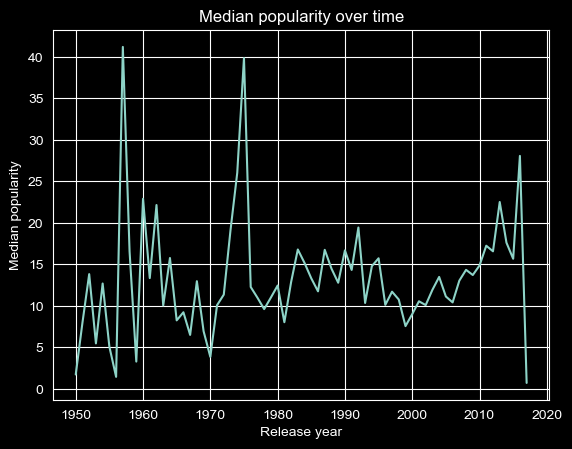

In [95]:
plot_df = df.dropna(subset=["release_year", "popularity"]).copy()
plot_df = plot_df[(plot_df["release_year"] >= 1950) & (plot_df["release_year"] <= 2020)]

pop_by_year = plot_df.groupby("release_year")["popularity"].median()

plt.figure()
plt.plot(pop_by_year.index, pop_by_year.values)
plt.xlabel("Release year")
plt.ylabel("Median popularity")
plt.title("Median popularity over time")
plt.show()

## Deep dive helpers: selecting a film + finding comparable peers

To support stakeholder decisions, we define a simple and explainable comparison method:

- Find a movie by title (exact match, with a fallback search)
- Build a “peer group” based on:
  - similar genre (via `primary_genre`)
  - similar release window (context of the era)
  - similar budget band (so comparisons are fair)

This sets up the two deep dives as a *business argument*:
why one film is a strong anchor and why another should be positioned differently.

In [96]:
def get_movie(df, title):
    m = df[df["title"].str.lower() == title.lower()]
    if len(m) == 0:
        # fallback: contains search
        m = df[df["title"].str.lower().str.contains(title.lower(), na=False)]
    return m.head(1)

def budget_band_peers(df, movie_row, year_window=5, budget_factor=(0.5, 2.0)):
    year = movie_row["release_year"]
    genre = movie_row.get("primary_genre", np.nan)
    budget = movie_row["budget"]

    peers = df.copy()

    # similar genre if possible
    if pd.notna(genre):
        peers = peers[peers["primary_genre"] == genre]

    # year window
    if pd.notna(year):
        peers = peers[(peers["release_year"] >= year - year_window) & (peers["release_year"] <= year + year_window)]

    # budget band
    if pd.notna(budget) and budget > 0:
        low = budget * budget_factor[0]
        high = budget * budget_factor[1]
        peers = peers[(peers["budget"] >= low) & (peers["budget"] <= high)]

    # drop itself by id if possible
    if "id" in movie_row.index and "id" in peers.columns:
        peers = peers[peers["id"] != movie_row["id"]]

    return peers

## Deep dive 1: Rocky (1976) — why it’s a strong catalogue anchor

We choose **Rocky** because it’s:
- highly recognizable (reduces adoption friction)
- a strong example of market traction (via ROI/profit where available)
- thematically clear (keywords enable powerful marketing language)

The goal is not to copy theatrical economics, but to show how this dataset supports
**anchor selection + campaign messaging** for the rental shop.

In [97]:
rocky = get_movie(df, "Rocky").iloc[0]
rocky

id                                                                         1366
title                                                                     Rocky
original_title                                                            Rocky
release_date                                                         1976-11-21
release_year                                                             1976.0
original_language                                                            en
overview                      When world heavyweight boxing champion, Apollo...
status                                                                 Released
tagline                               His whole life was a million-to-one shot.
primary_genre                                                             Drama
genres                                            [{"id": 18, "name": "Drama"}]
keywords                      [{"id": 240, "name": "underdog"}, {"id": 276, ...
production_companies                    

## Rocky vs peers: contextualize the result

A single movie’s numbers are hard to interpret without context.
Here we compare Rocky to similar films (genre + era + budget band) and rank by ROI.

This supports a stakeholder-friendly takeaway:
Rocky isn’t just “good” — it is unusually strong relative to its peer group,
which is why it deserves “anchor” status in the catalogue and promotions.

In [98]:
rocky_peers = budget_band_peers(df.dropna(subset=["budget","revenue"]), rocky, year_window=8)
rocky_peers = rocky_peers.dropna(subset=["profit","roi"])

summary_cols = ["title","release_year","primary_genre","budget","revenue","profit","roi","vote_average","vote_count"]
rocky_comparison = rocky_peers[summary_cols].sort_values("roi", ascending=False).head(10)
rocky_comparison

,title,release_year,primary_genre,budget,revenue,profit,roi,vote_average,vote_count
id,,,,,,,,,
11298,The Howling,1981.0,Drama,1000000.0,17985893.0,16985893.0,17.985893,6.4,161
203,Mean Streets,1973.0,Drama,500000.0,3000000.0,2500000.0,6.000000,7.2,345
29146,Charly,1968.0,Drama,950000.0,814666.0,-135334.0,0.857543,6.6,28


## Rocky tags: turning metadata into marketing

Keywords and genres are the bridge from data to customer persuasion.

This output can directly inform:
- shelf signage (“Underdog Classics”, “Sports Motivation”)
- staff picks
- targeted email/social campaigns
- future recommendation logic based on tag overlap

In [99]:
rocky["genres_names"], rocky["keywords_names"][:15]

(['Drama'],
 ['underdog',
  'philadelphia',
  'transporter',
  'italo-american',
  'fight',
  "love of one's life",
  'publicity',
  'boxer',
  'independence',
  'boxing match',
  'training',
  'lovers',
  'surprise',
  'world champion',
  'amateur'])

## Deep dive 2: The Lone Ranger (2013)

We choose **The Lone Ranger** because it represents the opposite case:
- high budget does not guarantee strong outcomes
- it shows why we should not stock purely based on “big production”

For rentals, this becomes a **positioning decision**:
treat it as a niche/event rental (Western/Adventure bundles) rather than a core anchor.

In [100]:
lone = get_movie(df, "The Lone Ranger").iloc[0]
lone

id                                                                        57201
title                                                           The Lone Ranger
original_title                                                  The Lone Ranger
release_date                                                         2013-07-03
release_year                                                             2013.0
original_language                                                            en
overview                      The Texas Rangers chase down a gang of outlaws...
status                                                                 Released
tagline                                                 Never Take Off the Mask
primary_genre                                                            Action
genres                        [{"id": 28, "name": "Action"}, {"id": 12, "nam...
keywords                      [{"id": 1556, "name": "texas"}, {"id": 2673, "...
production_companies          [{"name": 

## The Lone Ranger vs peers: underperformance in context

We compare The Lone Ranger to similar films (genre + era + budget band) and rank by profit.

This supports a stakeholder message:
when two films look similar in “budget class”, their results can differ drastically,
so the business should use demand + tags to decide whether to stock heavily or test cautiously.

In [101]:
lone_peers = budget_band_peers(df.dropna(subset=["budget","revenue"]), lone, year_window=5)
lone_peers = lone_peers.dropna(subset=["profit","roi"])

lone_comparison = lone_peers[summary_cols].sort_values("profit").head(10)
lone_comparison

,title,release_year,primary_genre,budget,revenue,profit,roi,vote_average,vote_count
id,,,,,,,,,
76649,Pompeii,2014.0,Action,130000000.0,117831631.0,-12168369.0,0.906397,5.2,1267
81005,Jack the Giant Slayer,2013.0,Action,195000000.0,197687603.0,2687603.0,1.013783,5.5,2598
49529,John Carter,2012.0,Action,260000000.0,284139100.0,24139100.0,1.092843,6.1,2124
13183,Watchmen,2009.0,Action,130000000.0,185258983.0,55258983.0,1.425069,7.0,2811
117251,White House Down,2013.0,Action,150000000.0,205366737.0,55366737.0,1.369112,6.4,1891
43074,Ghostbusters,2016.0,Action,144000000.0,229147509.0,85147509.0,1.591302,5.3,2142
20662,Robin Hood,2010.0,Action,200000000.0,310669540.0,110669540.0,1.553348,6.2,1398
49040,The Bourne Legacy,2012.0,Action,130000000.0,276572938.0,146572938.0,2.127484,6.0,2651
188927,Star Trek Beyond,2016.0,Action,185000000.0,343471816.0,158471816.0,1.856604,6.6,2568


## The Lone Ranger tags: how to sell it if we stock it

Even when a film underperforms theatrically, the tags can still make it useful for rentals.

Keywords tell us:
- the likely audience segment (Western/Adventure fans)
- how to bundle it (theme nights, genre bundles, actor-driven collections)
- what recommendation links to build (shared keywords with stronger anchor titles)

In [102]:
lone["genres_names"], lone["keywords_names"][:15]

(['Action', 'Adventure', 'Western'],
 ['texas',
  'horse',
  'survivor',
  'texas ranger',
  'partner',
  'outlaw',
  'escape',
  'lawyer',
  'train',
  'lone ranger',
  'comanche',
  'the lone ranger',
  'tonto'])